In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# GPU если доступно, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [ ]:
# пути к распакованному датасету
train_dir = 'archive-4/seg_train/seg_train'
test_dir = 'archive-4/seg_test/seg_test'

# трансформации для обучающей выборки (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.5), # Случайное отражение по горизонтали
    transforms.RandomRotation(10),          # Небольшой поворот
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # стандартная нормализация ImageNet
])

# трансформации для тестовой выборки (только ресайз и нормализация)
test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# загрузка датасетов
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# создание DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# сохраняем названия классов
classes = train_dataset.classes
print(f"Классы: {classes}")

Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
class SceneClassifierCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SceneClassifierCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # после 3 пулингов размер картинки 150 - 75 - 37 - 18 (18x18)
        self.fc1 = nn.Linear(128 * 18 * 18, 512)
        self.dropout = nn.Dropout(0.5) # борьба с переобучением
        self.fc2 = nn.Linear(512, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1) # flatten (вытягиваем в вектор)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SceneClassifierCNN(num_classes=len(classes)).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):
    # обучение
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total

    # проверка
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_test_loss = val_loss / len(test_loader.dataset)
    epoch_test_acc = correct / total

    # сохраняем историю
    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    train_accs.append(epoch_train_acc)
    test_accs.append(epoch_test_acc)

    print(f"Эпоха {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.4f}")

Эпоха 1/50 | Train Loss: 0.4840, Acc: 0.8321 | Test Loss: 0.4447, Acc: 0.8507
Эпоха 2/50 | Train Loss: 0.4514, Acc: 0.8395 | Test Loss: 0.4321, Acc: 0.8603
Эпоха 3/50 | Train Loss: 0.4377, Acc: 0.8439 | Test Loss: 0.4562, Acc: 0.8463
Эпоха 4/50 | Train Loss: 0.4204, Acc: 0.8499 | Test Loss: 0.4368, Acc: 0.8580
Эпоха 5/50 | Train Loss: 0.4040, Acc: 0.8559 | Test Loss: 0.4177, Acc: 0.8633
Эпоха 6/50 | Train Loss: 0.3846, Acc: 0.8635 | Test Loss: 0.4429, Acc: 0.8670
Эпоха 7/50 | Train Loss: 0.3980, Acc: 0.8604 | Test Loss: 0.3993, Acc: 0.8680
Эпоха 8/50 | Train Loss: 0.3748, Acc: 0.8662 | Test Loss: 0.4034, Acc: 0.8677
Эпоха 9/50 | Train Loss: 0.3547, Acc: 0.8715 | Test Loss: 0.4330, Acc: 0.8703
Эпоха 10/50 | Train Loss: 0.3365, Acc: 0.8796 | Test Loss: 0.6020, Acc: 0.8477
Эпоха 11/50 | Train Loss: 0.3449, Acc: 0.8748 | Test Loss: 0.4059, Acc: 0.8750
Эпоха 12/50 | Train Loss: 0.3235, Acc: 0.8827 | Test Loss: 0.4003, Acc: 0.8770
Эпоха 13/50 | Train Loss: 0.3187, Acc: 0.8821 | Test Loss: 0.

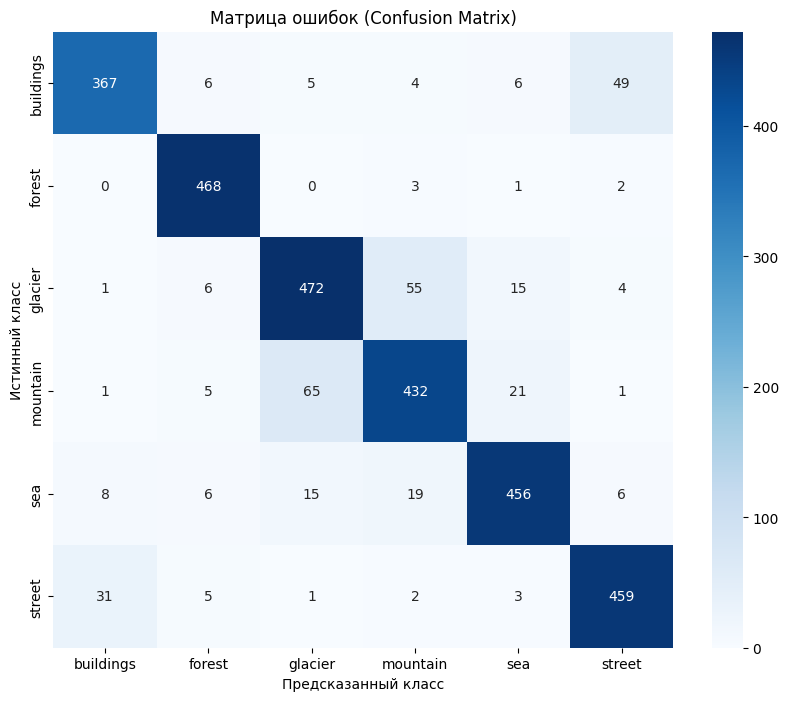

In [ ]:
# получение предсказаний для всей тестовой выборки
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# построение матрицы ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def predict_single_image(model, image_path, class_names, device):
    """
    Функция для предсказания класса одиночного изображения.

    Параметры:
    - model: Обученная модель PyTorch
    - image_path (str): Путь к файлу изображения
    - class_names (list): Список названий классов
    - device: 'cpu' или 'cuda'
    """

    # трансформации (строго как для тестовой выборки!)
    transform = transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # загрузка изображения с помощью PIL
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Ошибка загрузки изображения: {e}")
        return

    # предобработка: применяем трансформации
    img_tensor = transform(img)

    # модель ожидает тензор формы [Batch_size, Channels, Height, Width]
    # Наш img_tensor имеет форму [Channels, Height, Width]
    # Поэтому добавляем фиктивное измерение батча [1, Channels, Height, Width]
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # переводим модель в режим инференса (отключаем Dropout и фиксируем BatchNorm)
    model.eval()

    # получаем предсказание (без вычисления градиентов для экономии памяти)
    with torch.no_grad():
        outputs = model(img_tensor)

        # переводим "сырые" логиты в вероятности от 0 до 1
        probabilities = F.softmax(outputs, dim=1)

        # находим индекс максимальной вероятности и само значение вероятности
        confidence, predicted_idx = torch.max(probabilities, 1)

    # расшифровываем результат
    predicted_label = class_names[predicted_idx.item()]
    confidence_score = confidence.item() * 100

    # визуализация результата
    plt.figure(figsize=(6, 6))
    plt.imshow(img) # Показываем оригинальное неискаженное изображение
    plt.axis('off')

    # красим заголовок в зеленый цвет, если уверенность больше 70%, иначе в оранжевый
    color = 'green' if confidence_score > 70 else 'orange'
    plt.title(f"Предсказание: {predicted_label}\nУверенность: {confidence_score:.2f}%",
              fontsize=14, color=color)
    plt.show()

    return predicted_label, confidence_score

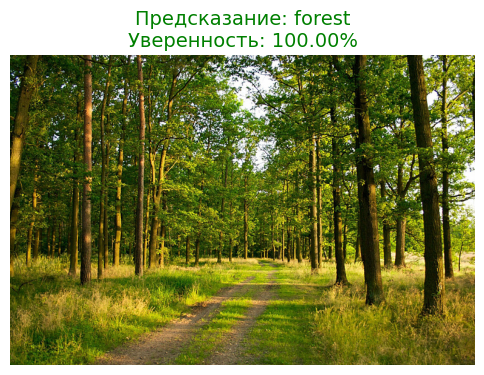

('forest', 100.0)

In [ ]:
predict_single_image(model, "/content/031y5mlzuvo0k5ziurkv30837ctz9qpd.jpg", classes, "cuda")

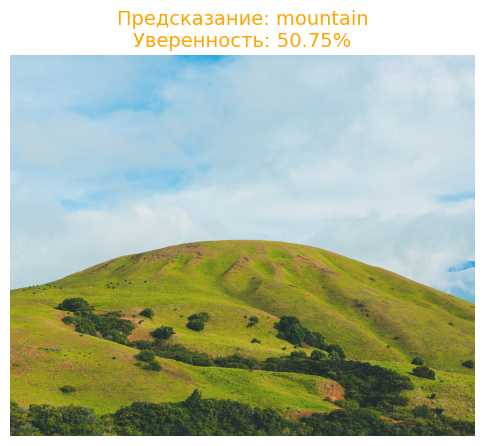

('mountain', 50.75066089630127)

In [ ]:
predict_single_image(model, "/content/5cf8d054a208e.jpg", classes, "cuda")

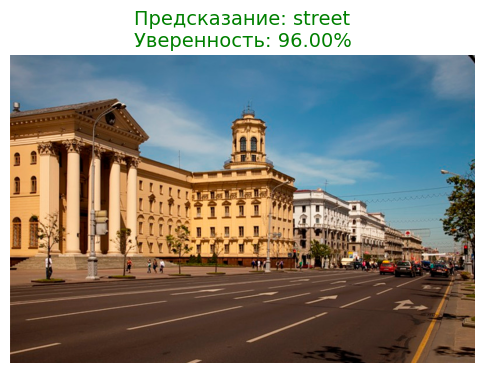

('street', 96.00185751914978)

In [ ]:
predict_single_image(model, "/content/9_prt_nez.png", classes, "cuda")

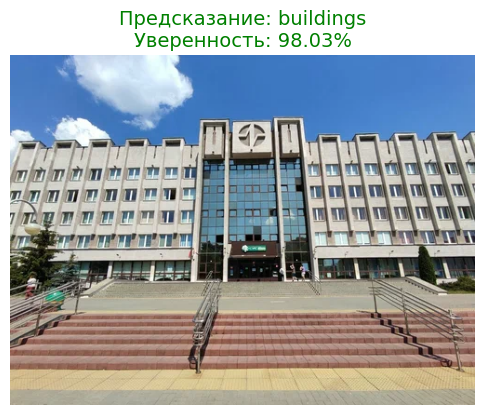

('buildings', 98.03372025489807)

In [ ]:
predict_single_image(model, "/content/L_height.webp", classes, "cuda")

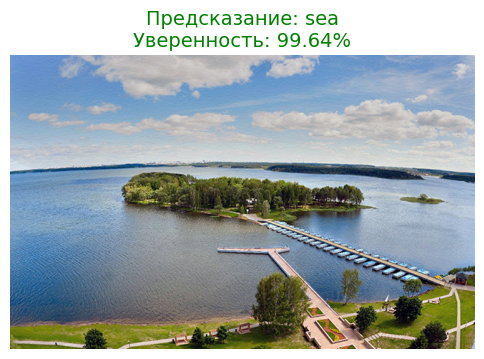

('sea', 99.64126944541931)

In [ ]:
predict_single_image(model, "/content/minskoe-more-belarus.jpg", classes, "cuda")